## Ejercicio 2.

Diseñe e implemente un algoritmo genético que **busque el mejor subconjunto de caracterı́sticas para la clasificación de cáncer** (leucemia linfocı́tica aguda y leucemia mielógena aguda) a partir de datos genómicos. Se proveen 38 muestras en el conjunto de entrenamiento y 34 en el conjunto de prueba (*leukemia train.csv* y *leukemia test.csv*, respectivamente). Cada muestra se compone de un *total de 7129 caracterı́sticas*, que corresponden a valores de expresión génica.


In [9]:
import numpy as np
import random 
import pandas as pd

In [10]:
def decodificar(individuo,tabla): 
    return tabla[:, individuo == 1]
 

In [ ]:
# from sklearn.neural_network import MLPClassifier
from sklearn import svm
from sklearn.metrics import accuracy_score

def funcion_aptitud(individuo,tabla,tabla_test):
    tabla_X = tabla[:,:-1]
    X_train = decodificar(individuo,tabla_X)
    y_train = tabla[:,-1]

    tabla_X_test = tabla_test[:,:-1]
    X_test = decodificar(individuo,tabla_X_test)
    y_test = tabla_test[:,-1]

    #mlp = MLPClassifier(hidden_layer_sizes=(10), activation='logistic', learning_rate_init=1, max_iter=500)
    #mlp.fit(X_train, y_train)
    #y_pred = mlp.predict(X_test)

    vector_machine = svm.SVC(kernel='sigmoid', random_state=42)
    vector_machine.fit(X_train, y_train)
    y_pred = vector_machine.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    

    fitness = accuracy
    return fitness

In [12]:
def evaluar_poblacion(poblacion,tabla,tabla_test):
    aptitudes = np.zeros(poblacion.shape[0])
    for i in range(poblacion.shape[0]):
        aptitud = funcion_aptitud(poblacion[i,:],tabla,tabla_test)
        aptitudes[i] = aptitud
    return aptitudes 
    

In [13]:
def seleccion_natural(aptitudes):
    orden = np.arange(0,aptitudes.shape[0])
    matriz = np.c_[aptitudes,orden]

    indices = np.argsort(matriz[:, 0])[::-1]
    matriz = matriz[indices]

    cantVentanas = 10
    venta_act = 0

    padres = np.zeros((cantVentanas,))

    while venta_act<cantVentanas:
        tam_ventana = int((aptitudes.shape[0]-1)*((cantVentanas-venta_act)/cantVentanas))
        padres[venta_act] = matriz[random.randint(0,tam_ventana),1]
        venta_act += 1

    return padres

In [14]:
def operador_variacion(poblacion,padres,ind_mejorAptitud):
    nueva_poblacion = [poblacion[ind_mejorAptitud,:].copy()]

    prob_mutacion = 10 #%
    #mutacion
    for i in range(padres.shape[0]-1):
        padre = int(padres[i])
        cromosoma_nuevo = poblacion[padre,:].copy()
        if(random.randint(0,100)<prob_mutacion):
            cant_genes_a_mutar = random.randint(1, 15)
            for _ in range(cant_genes_a_mutar):
                bit_mutar = random.randint(0, poblacion.shape[1] - 1)
                cromosoma_nuevo[bit_mutar] = not(cromosoma_nuevo[bit_mutar])
        nueva_poblacion.append(cromosoma_nuevo)


    #cruza
    for i in range(padres.shape[0]): 
        for j in range(i+1,padres.shape[0]):
            cant_bit_intercambio = random.randint(1,poblacion.shape[1]-1)
            padre1 = int(padres[i])
            padre2 = int(padres[j])
            hijo1 = np.r_[poblacion[padre1,0:cant_bit_intercambio],poblacion[padre2,cant_bit_intercambio:]]
            hijo2 = np.r_[poblacion[padre2,0:cant_bit_intercambio],poblacion[padre1,cant_bit_intercambio:]]
            nueva_poblacion.append(hijo1)
            nueva_poblacion.append(hijo2)

    poblacion = np.array(nueva_poblacion)
    return poblacion         

In [ ]:
import matplotlib.pyplot as plt
def graficar(hist_aptitudes): 
    # hist_aptitudes tiene forma (individuos, generaciones)
    generaciones = np.arange(hist_aptitudes.shape[1])
                
    # Calculo en los individuos (filas)
    maximos = np.max(hist_aptitudes, axis=0)
    minimos = np.min(hist_aptitudes, axis=0)
    promedios = np.mean(hist_aptitudes, axis=0)
                
    plt.figure(figsize=(9, 5))
    plt.plot(generaciones, maximos, label="Mejor aptitud (Máximo)", color="green")
    plt.plot(generaciones, promedios, label="Aptitud promedio", color="blue", linestyle="--")
    plt.plot(generaciones, minimos, label="Peor aptitud (Mínimo)", color="red")
                
    plt.xlabel("Generación")
    plt.ylabel("Aptitud")
    plt.title("Historial de convergencia del Algoritmo Evolutivo")
    plt.grid(True, linestyle=":", alpha=0.7)
    plt.legend()
    plt.show()

0.8823529411764706
0.8823529411764706
0.8823529411764706
0.8823529411764706
0.8823529411764706
0.8823529411764706
0.8823529411764706
0.8823529411764706
0.8823529411764706
0.8823529411764706
0.8823529411764706
0.9117647058823529
0.9411764705882353
0.9411764705882353
0.9411764705882353
0.9411764705882353
0.9411764705882353
0.9411764705882353
0.9411764705882353
0.9411764705882353
0.9411764705882353
0.9411764705882353
0.9411764705882353
0.9411764705882353
0.9411764705882353
0.9411764705882353
0.9411764705882353
0.9411764705882353
0.9411764705882353
0.9411764705882353
0.9411764705882353
0.9411764705882353
0.9411764705882353
0.9411764705882353
0.9411764705882353
0.9411764705882353
0.9705882352941176
0.9705882352941176
0.9705882352941176
0.9705882352941176
0.9705882352941176
0.9705882352941176
0.9705882352941176
0.9705882352941176
0.9705882352941176
0.9705882352941176
0.9705882352941176
0.9705882352941176
0.9705882352941176
0.9705882352941176
0.9705882352941176
0.9705882352941176
0.9705882352

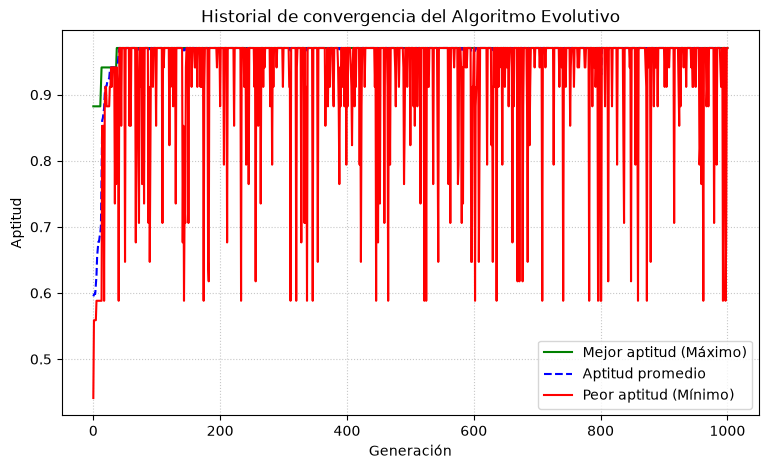

In [16]:

N = 100
cantBitsInd = 7129
cant_max_generaciones = 1000

pro_uno = 0.002
poblacion = (np.random.rand(N,cantBitsInd) < pro_uno).astype(int)

tabla = pd.read_csv("leukemia_train.csv",header=None).to_numpy()
tabla_test = pd.read_csv("leukemia_test.csv",header=None).to_numpy()

aptitudes = evaluar_poblacion(poblacion,tabla,tabla_test)
mejorAptidud = np.max(aptitudes) 
ind_mejorAptitud = np.argmax(aptitudes)

generacion = 0
aptitudDeseada = 0.98

histAptitudes = [aptitudes]

while  mejorAptidud<aptitudDeseada and generacion < cant_max_generaciones:
    padres = seleccion_natural(aptitudes)
    poblacion = operador_variacion(poblacion,padres,ind_mejorAptitud)
    aptitudes = evaluar_poblacion(poblacion,tabla,tabla_test)
    mejorAptidud = np.max(aptitudes) 
    ind_mejorAptitud = np.argmax(aptitudes)
    histAptitudes.append(aptitudes)
    generacion += 1
    print(mejorAptidud)

indiceMejorAptitud = np.argmax(aptitudes)
cromosoma = poblacion[indiceMejorAptitud,:]

print(generacion)

histAptitudes = np.array(histAptitudes).T
graficar(histAptitudes)